# **RQ1**: Number of neighbors per node over time

Costruisco il grafo con igraph, con attributi di token, peso archi e freq parola

In [ ]:
# import pandas as pd
# import igraph as ig
# from pathlib import Path
# import time

# edges_dir = Path("../edges_analysis/edges")
# vec_dir = Path("../embedding/word_embeddings_cleaned")
# freq_dir = Path("../embedding/freq snap"
# )

# output_dir = Path("igraph_graphs")
# output_dir.mkdir(exist_ok=True)

# percentile = 99

# print("[START] Costruzione grafi igraph con freq nodo")

# for snap in range(1, 11):
#     t0 = time.time()

#     edges_tsv = edges_dir / f"edges_snap{snap}_p{percentile}.tsv"
#     vec_file = vec_dir / f"fasttext_snap{snap}_filt.vec"
#     freq_file = freq_dir / f"vocab_freq_snap{snap}.txt"
#     out_graph = output_dir / f"graph_snap{snap}_p{percentile}.igp"

#     print(f"\n[SNAPSHOT {snap}]")

#     # ---------- ARCHI ----------
#     df_edges = pd.read_csv(edges_tsv, sep="\t")

#     src = df_edges.iloc[:, 0].astype(int).to_numpy()
#     dst = df_edges.iloc[:, 1].astype(int).to_numpy()

#     has_weight = df_edges.shape[1] > 2
#     if has_weight:
#         weights = df_edges.iloc[:, 2].astype(float).to_numpy()

#     # ---------- TOKEN ----------
#     tokens = []
#     with open(vec_file, encoding="utf-8") as f:
#         next(f)
#         for line in f:
#             tokens.append(line.split()[0])

#     n_nodes = len(tokens)

#     # ---------- FREQUENZE ----------
#     freq_map = {}
#     with open(freq_file, encoding="utf-8") as f:
#         for line in f:
#             token, freq = line.split()
#             freq_map[token] = int(freq)

#     # allineamento token → freq (0 se assente)
#     freqs = [freq_map.get(tok, 0) for tok in tokens]

#     # ---------- GRAFO ----------
#     g = ig.Graph(n=n_nodes, directed=False)

#     g.vs["token"] = tokens
#     g.vs["freq"] = freqs

#     g.add_edges(zip(src, dst))

#     if has_weight:
#         g.es["weight"] = weights

#     # ---------- SALVATAGGIO ----------
#     g.write_pickle(out_graph)

#     print(
#         f"[DONE] nodi={n_nodes}, archi={g.ecount()}, "
#         f"freq=yes, peso={'sì' if has_weight else 'no'} "
#         f"in {time.time() - t0:.2f}s"
#     )

# print("\n[TOTAL] Tutti i grafi salvati")


Per ogni nodo in ogni snapshot calcolo e scrivo su un file csv il grado.

In [ ]:
import pandas as pd
import igraph as ig
from pathlib import Path
import time

graph_dir = Path("igraph_graphs")        
output_dir = Path("degree_csv_igraph_snapshot")
output_dir.mkdir(exist_ok=True)

percentile = 99

print("[START] Estrazione degree dai grafi igraph")

for snap in range(1, 11):
    t0 = time.time()

    graph_file = graph_dir / f"graph_snap{snap}_p{percentile}.igp"
    output_csv = output_dir / f"node_degree_snap{snap}_p{percentile}.csv"

    print(f"\n[SNAPSHOT {snap}]")

    # importo g
    g = ig.Graph.Read_Pickle(graph_file)

   
    degrees = g.degree()   # numero di vicini

   
    tokens = g.vs["token"]

    df_out = pd.DataFrame({
        "token": tokens,
        "degree": degrees
    })

    df_out.to_csv(output_csv, index=False)

    print(
        f"[DONE] nodi={g.vcount()}, archi={g.ecount()} "
        f"in {time.time() - t0:.2f}s"
    )

print("\n[TOTAL] Tutti i CSV generati")


Calcolo shrinkage individuale per ogni nodo in ogni istante. Come t0 baseline metto il primo snap in cui appare la parola

In [ ]:
import pandas as pd
from pathlib import Path

degree_dir = Path("degree_csv_igraph_snapshot")
output_csv = Path("shrinkage_i.csv")

snapshots = range(1, 11)

# --- leggo tutti i degree ---
all_degrees = {}  # all_degrees[snap][token] = degree
for snap in snapshots:
    df = pd.read_csv(degree_dir / f"node_degree_snap{snap}_p99.csv")
    
    # Convertiamo i token in stringa e ignoriamo NaN
    df = df.dropna(subset=["token"])
    df["token"] = df["token"].astype(str)
    
    all_degrees[snap] = dict(zip(df["token"], df["degree"]))

# --- trovo primo snapshot per ogni token ---
first_snap = {}
for snap in snapshots:
    for token in all_degrees[snap]:
        if token not in first_snap:
            first_snap[token] = snap

# --- calcolo in quanti snapshot compare ogni token ---
appear_count = {token: 0 for token in first_snap}
for snap in snapshots:
    for token in first_snap:
        if all_degrees[snap].get(token, 0) > 0:
            appear_count[token] += 1

# --- filtro token: almeno 5 snapshot ---
tokens = sorted([tok for tok, count in appear_count.items() if count >= 5])

# --- calcolo shrinkage per tutti i token filtrati ---
shrinkage_data = {"token": tokens}

for snap in snapshots:
    shrink_values = []
    for token in tokens:
        t0 = first_snap[token]
        degree_t0 = all_degrees[t0].get(token, 0)
        degree_t = all_degrees[snap].get(token, 0)  # se non presente → 0
        if degree_t0 == 0:
            s = None  # baseline assente
        else:
            s = 1 - (degree_t / degree_t0)
        shrink_values.append(s)
    shrinkage_data[f"shrinkage_snap{snap}"] = shrink_values

df_shrink_filtered = pd.DataFrame(shrinkage_data)
df_shrink_filtered.to_csv(output_csv, index=False)

print(f"[DONE] Shrinkage calcolato per token in ≥5 snapshot in {output_csv}")


In [ ]:
len(df_shrink_filtered)

Calcolo S aggregato per ogni nodo

In [ ]:
import pandas as pd
from pathlib import Path

# CSV shrinkage
shrink_csv = "shrinkage_i.csv"
df_shrink = pd.read_csv(shrink_csv)

snapshots = range(1, 11)
freq_dir = Path(r"../embedding/freq snap")

# df delle frequenze per tutti gli snapshot
freq_dfs = []
for snap in snapshots:
    freq_file = freq_dir / f"vocab_freq_snap{snap}.txt"
    df_freq = pd.read_csv(
        freq_file,
        sep=" ",
        names=["token", f"freq_snap{snap}"],
        dtype={"token": str, f"freq_snap{snap}": int}
    )
    # --- filtriamo solo token presenti in shrinkage_i.csv ---
    df_freq = df_freq[df_freq["token"].isin(df_shrink["token"])]
    freq_dfs.append(df_freq)

# Merge di tutte le frequenze in un unico DataFrame
df_freq_all = freq_dfs[0]
for df_f in freq_dfs[1:]:
    df_freq_all = df_freq_all.merge(df_f, on="token", how="outer")

# allineiamo df_shrink e df_freq_all
df_all = df_shrink.merge(df_freq_all, on="token", how="inner")  # inner perché vogliamo solo token comuni

# numeratore e denominatore vettorialmente
numeratore = 0
denominatore = 0
for snap in snapshots:
    s_col = f"shrinkage_snap{snap}"
    w_col = f"freq_snap{snap}"
    # peso NaN → 0, shrinkage NaN → 0
    numeratore += df_all[s_col].fillna(0) * df_all[w_col].fillna(0)
    denominatore += df_all[w_col].fillna(0)

# S_aggregato
df_all["S_aggregato"] = numeratore / denominatore
df_result = df_all[["token", "S_aggregato"]]

df_result.to_csv("shrinkage_aggr_filtered.csv", index=False)
print(df_result.head())


In [ ]:
len(df_result)

Statistiche descrittive

In [ ]:
import pandas as pd

df = pd.read_csv("shrinkage_aggr_filtered.csv")

df["S_aggregato"].describe()


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["S_aggregato"].dropna(), bins=50, color="skyblue", edgecolor="black")
plt.xlabel("Aggregated Shrinkage (S_aggregato)", fontsize=12)
plt.ylabel("Number of Tokens", fontsize=12)
plt.title("Distribution of Aggregated Shrinkage", fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.show()


In [ ]:
plt.figure()
plt.boxplot(df["S_aggregato"].dropna(), vert=False)
plt.xlabel("S_aggregato")
plt.title("Boxplot di S_aggregato")
plt.show()


In [ ]:
import numpy as np

df["class"] = np.where(
    df["S_aggregato"] > 0, "shrinkage",
    np.where(df["S_aggregato"] < 0, "expansion")
)

df["class"].value_counts(normalize=True) * 100

# % token che perdono vicini
# % che li guadagnano


In [ ]:
# top parole con espansione forte
df.sort_values("S_aggregato", ascending=True).head(20)

In [ ]:
# top parole con shrinkage forte
df.sort_values("S_aggregato", ascending=False).head(20)

Vedo la correlazione tra shrinkage e frequenza

In [3]:
import pandas as pd
from pathlib import Path

# --- shrinkage ---
df_shrink = pd.read_csv("shrinkage_i.csv")

# --- frequenze ---
snapshots = range(1, 11)
freq_dir = Path("../embedding/freq snap")

freq_dfs = []
for snap in snapshots:
    f = freq_dir / f"vocab_freq_snap{snap}.txt"
    df = pd.read_csv(
        f,
        sep=" ",
        names=["token", f"freq_snap{snap}"],
        dtype={"token": str, f"freq_snap{snap}": int}
    )
    freq_dfs.append(df)

df_freq_all = freq_dfs[0]
for df in freq_dfs[1:]:
    df_freq_all = df_freq_all.merge(df, on="token", how="outer")

# --- merge finale ---
df_all = df_shrink.merge(df_freq_all, on="token", how="outer")


In [4]:
snapshots = range(1, 10)
rows = []

for snap in snapshots:
    Si = df_all[f"shrinkage_snap{snap}"].fillna(0)

    F_t  = df_all[f"freq_snap{snap}"].fillna(0)
    F_t1 = df_all[f"freq_snap{snap+1}"].fillna(0)

    delta_F = F_t1 - F_t

    rows.append(pd.DataFrame({
        "token": df_all["token"],
        "snap": snap,
        "Si_positive": (Si > 0),
        "delta_F_positive": (delta_F > 0)
    }))

df_sign = pd.concat(rows, ignore_index=True)


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

ct = pd.crosstab(
    df_sign["Si_positive"],
    df_sign["delta_F_positive"],
    normalize="index"
)

print(ct)


delta_F_positive     False     True 
Si_positive                         
False             0.741322  0.258678
True              0.517771  0.482229


In [6]:
trend = ct[True]   # P(delta_F_positive | Si_positive)

trend.index = ["Expansion (S ≤ 0)", "Shrinkage (S > 0)"]

print(trend)


Expansion (S ≤ 0)    0.258678
Shrinkage (S > 0)    0.482229
Name: True, dtype: float64


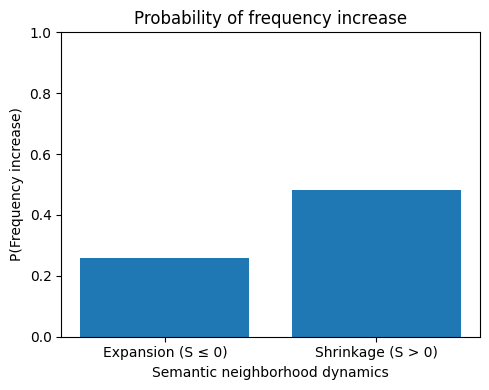

In [7]:
plt.figure(figsize=(5,4))
plt.bar(
    trend.index,
    trend.values
)

plt.ylabel("P(Frequency increase)")
plt.xlabel("Semantic neighborhood dynamics")
plt.title("Probability of frequency increase")

plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [8]:
import scipy.stats as stats

# tabella di contingenza
ct = pd.crosstab(df_sign["Si_positive"], df_sign["delta_F_positive"])

# test chi-quadro
chi2, p, dof, expected = stats.chi2_contingency(ct)

print("Chi2:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:\n", expected)


Chi2: 46554.30687407566
p-value: 0.0
Degrees of freedom: 1
Expected frequencies:
 [[729074.05882917 313473.94117083]
 [168677.94117083  72525.05882917]]


Calcolo le parole che risentono più dell'effetto shrinkage e freq in aumento

In [ ]:
import pandas as pd

# Partiamo da df_sign e df_all (che contiene freq)
# Calcoliamo ΔFreq per ogni token e snapshot
snapshots = range(1, 10)

rows = []

for snap in snapshots:
    Si = df_all[f"shrinkage_snap{snap}"].fillna(0)
    F_t  = df_all[f"freq_snap{snap}"].fillna(0)
    F_t1 = df_all[f"freq_snap{snap+1}"].fillna(0)
    delta_F = F_t1 - F_t

    rows.append(pd.DataFrame({
        "token": df_all["token"],
        "snap": snap,
        "Si_positive": Si > 0,
        "delta_F": delta_F
    }))

df_delta = pd.concat(rows, ignore_index=True)

# Filtriamo solo token con Si positivo e ΔFreq > 0
df_effect = df_delta[(df_delta["Si_positive"]) & (df_delta["delta_F"] > 0)]

# Raggruppiamo per token e calcoliamo somma o media dell'aumento
top_tokens = df_effect.groupby("token")["delta_F"].sum().sort_values(ascending=False)

# Mostriamo le prime 20
pd.set_option('display.max_rows', None)
print(top_tokens.head(200))



Creo un file con tutte le informazioni per il subset che ho analizzato (quello con le parole che appaiono in almeno 5 snap)
token_info_filtered_with_complexity.csv contiene il token, Si per ogni anno, Freq per ogni anno, S aggr, e poi le metriche di comlessità, quindi: char_len,syll_len,demauro_level,idf

In [ ]:
import pandas as pd
from pathlib import Path
import igraph as ig

# --- Percorsi ---
shrink_csv = "shrinkage_i.csv"
freq_dir = Path(r"../embedding/freq snap")
sagg_file = Path(r"shrinkage_aggr_filtered.csv")
graph_dir = Path(r"networks_annotated")
output_csv = "token_info_filtered_with_complexity.csv"

snapshots = range(1, 11)

# --- Carico shrinkage ---
df_shrink = pd.read_csv(shrink_csv)

# --- Carico frequenze per tutti gli snapshot ---
freq_dfs = []
for snap in snapshots:
    freq_file = freq_dir / f"vocab_freq_snap{snap}.txt"
    df_freq = pd.read_csv(
        freq_file,
        sep=" ",
        names=["token", f"freq_snap{snap}"],
        dtype={"token": str, f"freq_snap{snap}": int}
    )
    freq_dfs.append(df_freq)

# Merge di tutte le frequenze
df_freq_all = freq_dfs[0]
for df_f in freq_dfs[1:]:
    df_freq_all = df_freq_all.merge(df_f, on="token", how="outer")

# --- Filtra token presenti in almeno 5 snapshot ---
appear_count = (df_freq_all.iloc[:, 1:] > 0).sum(axis=1)
mask = appear_count >= 5
df_freq_all = df_freq_all[mask]

# --- Filtra df_shrink per token validi ---
df_shrink = df_shrink[df_shrink["token"].isin(df_freq_all["token"])]

# --- Merge shrinkage + frequenze ---
df_all = df_shrink.merge(df_freq_all, on="token", how="inner")

# --- Aggiungo S_aggregato dal file esterno ---
df_sagg = pd.read_csv(sagg_file)
df_all = df_all.merge(df_sagg, on="token", how="left")

# --- COSTRUISCO COMPLESSITÀ ---
complexity_data = {}

for snap in snapshots:
    graph_file = graph_dir / f"graph_snap{snap}_p99.igp"
    G = ig.Graph.Read_Pickle(graph_file)
    
    for v in G.vs:
        token = v["token"]
        if token not in complexity_data:
            complexity_data[token] = {
                "char_len": v["char_len"],
                "syll_len": v["syll_len"],
                "demauro_level": v["demauro_level"],
                "idf": v["idf"]
            }

# --- Merge complessità con df_all ---
df_complexity = pd.DataFrame.from_dict(complexity_data, orient="index").reset_index().rename(columns={"index": "token"})
df_all = df_all.merge(df_complexity, on="token", how="left")

# --- Salvataggio finale ---
df_all.to_csv(output_csv, index=False)
print(f"[DONE] CSV completo con complessità creato in {output_csv}")


In [ ]:
len(df_all)

Studio S aggr e complessità delle parole

In [ ]:
# G.vs["char_len"] -> lunghezza parola
# G.vs["syll_len"] -> lunghezza in termini di sillabe
# G.vs["demauro_level"] -> 0,1,2: appartiene al vocabolario di base; 3: non appartiene al vocabolario di base (i.e., è "complessa")
# G.vs["idf"] -> inverse document frquency (più è alta, più la parola è complessa)


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("token_info_filtered_with_complexity.csv")

cols = ["S_aggregato", "char_len", "syll_len", "demauro_level", "idf"]
df = df[cols].dropna()

# variabile binaria: restringimento vs espansione
df["S_sign"] = df["S_aggregato"] > 0


In [ ]:
from scipy.stats import spearmanr

metrics = ["char_len", "syll_len", "idf"]

for m in metrics:
    rho, p = spearmanr(df["S_aggregato"], df[m])
    print(f"{m:12s}  rho={rho:.3f}  p={p:.3g}")


In [ ]:
df["shrink"] = df["S_aggregato"] > 0

pd.crosstab(
    df["demauro_level"] == 3,   # parola complessa
    df["shrink"],
    normalize="index"
)


In [ ]:
from scipy.stats import chi2_contingency

ct = pd.crosstab(df["demauro_level"] == 3, df["shrink"])
chi2, p, _, _ = chi2_contingency(ct)
print(p)


Andamento shrinkage vs complessità idf

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df["shrink"] = df["S_aggregato"] > 0
# binning dell'idf
df["idf_bin"] = pd.qcut(df["idf"], q=20, duplicates="drop")

trend = (
    df.groupby("idf_bin")["shrink"]
      .mean()
)

# centro dei bin per l'asse x
x = [interval.mid for interval in trend.index]
y = trend.values
plt.figure(figsize=(6,4))
plt.plot(x, y, marker="o")

plt.xlabel("IDF (lexical complexity)")
plt.ylabel("P(Shrinkage)")
plt.title("Probability of semantic shrinkage vs lexical complexity")

plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df["shrink"] = df["S_aggregato"] > 0

# complessa = fuori dal VDB (demauro_level == 3)
df["complex"] = df["demauro_level"] == 3

trend = (
    df.groupby("complex")["shrink"]
      .mean()
)

trend.index = ["Non-complex", "Complex"]

print(trend)



plt.figure(figsize=(5,4))
plt.bar(
    trend.index,
    trend.values
)

plt.ylabel("P(Shrinkage)")
plt.xlabel("Lexical complexity")
plt.title("Probability of semantic shrinkage")

plt.ylim(0, 1)
plt.tight_layout()
plt.show()



